# Credit Mailer — Cleaning & Preparation, Path 3

One sequential pass, in the order you would actually run it:
profile → clean → engineer → select → scale → **fork** → the bandit.

**Dataset:** Karlan & Zinman's South African consumer-credit mailer experiment
(`data/adcontentworth_qje.tab.gz`) — 58,168 rows × 37 columns, three mailer waves sent by one
lender in 2003, each client offered a loan at a **randomly assigned** interest rate.

**The verdict convention.** Every section always runs its detection code. When a check finds
nothing to fix it prints `N/A` and the handling step is skipped rather than deleted, so the
notebook stays a complete checklist. Two badges are added to the framework's pair, because this
is a **path-isolated** run rather than a generic clean:

| badge | meaning |
| --- | --- |
| `APPLIES` | the check ran and there is work to do |
| `N/A` | the check ran and found nothing — always backed by a number printed on this run |
| `OVERRIDE` | the framework's default operation is **replaced** on this path |
| `BANNED` | forbidden on this path, and the message is the reason, not an apology |

**Why a path at all.** Steps 1–3 of the refinery are path-blind: they finish before the pipeline
knows what kind of target it is holding. Sections 1–7 below are that entryway. Section 7 is where
the geometry of `y` gets read, and from there this is Path 3 — the bandit — which bans three of
the remaining steps outright. Each ban is printed with the named engine that would break.

## 0. Setup

In [1]:
import gzip
import io
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

def verdict(applies, message, banned=False, override=False):
    """Section verdict. Returns the flag so callers can gate the handling step.

    Returns False for BANNED as well as for N/A, so `if verdict(...):` can never gate a
    handler the framework forbids.
    """
    label = ("BANNED   — " if banned
             else "OVERRIDE — " if override
             else "APPLIES  — " if applies
             else "N/A      — ")
    print(label + message)
    return bool(applies) and not banned

In [2]:
# The committed file is Dataverse's ingested TSV of the authors' Stata original, gzipped.
# The hash is checked rather than trusted: every figure in this notebook is a statement about
# these exact bytes, and a silently different file would make all of them wrong together.
RAW_PATH = Path("data/adcontentworth_qje.tab.gz")
EXPECTED_SHA256 = "6341d87b24abd1753e39e1c71f51ec09ebdb785970ed515f432d6b1bc0affd28"

raw_bytes = gzip.decompress(RAW_PATH.read_bytes())
actual = hashlib.sha256(raw_bytes).hexdigest()
assert actual == EXPECTED_SHA256, f"source file is not the one this notebook was written against"

df_raw = pd.read_csv(io.BytesIO(raw_bytes), sep="\t")   # TAB, not comma — it is a .tab
df = df_raw.copy()          # keep the untouched original for before/after comparisons
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"from {len(raw_bytes):,} bytes (sha256 verified)")

Loaded 58,168 rows x 37 columns from 5,980,352 bytes (sha256 verified)


## 1. First Look

The deposit ships one wide table and no documentation inside the file. What the columns mean
comes from the paper and from Dataverse's variable-level DDI; what is actually *in* them comes
from here.

In [3]:
df.head()

,wave,dormancy,race,risk,offer4,prize,intshown,trcount,tookup,applied,badacct_last,female,edhi,waved3,dphoto_female,dphoto_none,dphoto_black,gender_match,race_match,nspeakeligible,speak_trt,oneln_trt,comploss_n,use_any,deadlinemed,deadlinelong,deadlong_elig,deadshort_elig,amountbrw_unc,tookup_outside_only,deadlineshortext,tookup_after_short,applied_2weeks,tookup_after_med,tookup_after_long,stripany,comp_n
0,2,20,black,HIGH,9.69,1.0,1.0,16.0,0,0,NaN,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,1.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,16,black,HIGH,3.25,0.0,0.0,5.0,0,0,NaN,1,1,0,0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0,1.0,0.0,1.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,2,10,black,HIGH,4.44,0.0,1.0,17.0,0,0,NaN,1,0,0,1,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1,1.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,18,black,HIGH,9.00,0.0,1.0,14.0,0,0,NaN,1,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,2,13,black,HIGH,9.75,1.0,0.0,14.0,0,0,NaN,0,0,0,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0.0,1.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58168 entries, 0 to 58167
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   wave                 58168 non-null  int64  
 1   dormancy             58168 non-null  int64  
 2   race                 57870 non-null  object 
 3   risk                 58168 non-null  object 
 4   offer4               58168 non-null  float64
 5   prize                53194 non-null  float64
 6   intshown             53194 non-null  float64
 7   trcount              57911 non-null  float64
 8   tookup               58168 non-null  int64  
 9   applied              58168 non-null  int64  
 10  badacct_last         4381 non-null   float64
 11  female               58168 non-null  int64  
 12  edhi                 58168 non-null  int64  
 13  waved3               58168 non-null  int64  
 14  dphoto_female        58168 non-null  int64  
 15  dphoto_none          53194 non-null 

In [5]:
# Three columns carry the whole experiment: `wave` is when the mailer went out, `offer4` is the
# randomised price, `tookup` is the outcome.
df[["wave", "offer4", "tookup", "applied", "amountbrw_unc"]].describe().round(4)

,wave,offer4,tookup,applied,amountbrw_unc
count,58168.0000,58168.0000,58168.0000,58168.0000,58168.0000
mean,2.4680,7.9351,0.0753,0.0872,110.5299
std,0.6481,2.4714,0.2639,0.2821,531.2491
min,1.0000,3.2500,0.0000,0.0000,0.0000
25%,2.0000,5.9900,0.0000,0.0000,0.0000
50%,3.0000,7.9900,0.0000,0.0000,0.0000
75%,3.0000,10.0000,0.0000,0.0000,0.0000
max,3.0000,14.7500,1.0000,1.0000,10000.0000


In [6]:
df.describe(include="object")

,race,risk
count,57870,58168
unique,4,3
top,black,HIGH
freq,49305,43660


## 2. Data Types

The audit that matters here is not "is a number stored as text". It is the opposite, and it is
invisible in `head()`: **23 of the 30 binary columns arrive as `float64`**, for two different
reasons that look identical in `dtypes`. Fifteen carry NaN, and pandas has no integer type that
does. The other eight are spelled `0.0` in the file itself.

Left alone, every one of those columns writes itself to CSV as `1.0` instead of `1`, and a
`SMALLINT` column on the far end rejects the load.

In [7]:
# What pandas inferred, grouped by what the column actually represents.
binary_like = [c for c in df.columns
               if set(df[c].dropna().unique()) <= {0, 1, 0.0, 1.0}]
as_float = [c for c in binary_like if df[c].dtype == "float64"]
as_int = [c for c in binary_like if df[c].dtype == "int64"]

print(f"{len(binary_like)} columns hold only 0/1 values.")
print(f"   typed int64   : {len(as_int):>2}")
print(f"   typed float64 : {len(as_float):>2}")
print(f"   nulls in the int64 group : {sorted(int(v) for v in df[as_int].isna().sum().unique())}  (none, or")
print(f"                              they would not be int64)")

# Two different causes, and dtypes cannot tell them apart.
nulled = [c for c in as_float if df[c].isna().any()]
clean = [c for c in as_float if not df[c].isna().any()]
print(f"\n   {len(nulled)} are float64 because they carry NaN:")
print(f"      {nulled}")
print(f"\n   {len(clean)} are float64 with NO nulls at all:")
print(f"      {clean}")

# The second group is float because the FILE says so. Dataverse's ingest typed them continuous.
raw_header = raw_bytes.split(b"\n")[0].decode().split("\t")
raw_row = raw_bytes.split(b"\n")[1].decode().split("\t")
sample = dict(zip(raw_header, raw_row))
print(f"\n   and the file is why — the first data row, as literal text:")
for c in clean[:3] + as_int[:2]:
    print(f"      {c:<22} {sample[c]!r:>6}  -> {df[c].dtype}")
print("   Dataverse's DDI types exactly those eight as `contin`, so the TSV spells them with a")
print("   decimal point and pandas believes it.")

30 columns hold only 0/1 values.
   typed int64   :  7
   typed float64 : 23
   nulls in the int64 group : [0]  (none, or
                              they would not be int64)

   15 are float64 because they carry NaN:
      ['prize', 'intshown', 'badacct_last', 'dphoto_none', 'dphoto_black', 'gender_match', 'race_match', 'nspeakeligible', 'speak_trt', 'oneln_trt', 'comploss_n', 'deadlinemed', 'deadlinelong', 'deadlong_elig', 'deadshort_elig']

   8 are float64 with NO nulls at all:
      ['tookup_outside_only', 'deadlineshortext', 'tookup_after_short', 'applied_2weeks', 'tookup_after_med', 'tookup_after_long', 'stripany', 'comp_n']

   and the file is why — the first data row, as literal text:
      tookup_outside_only     '0.0'  -> float64
      deadlineshortext        '0.0'  -> float64
      tookup_after_short      '0.0'  -> float64
      tookup                    '0'  -> int64
      applied                   '0'  -> int64
   Dataverse's DDI types exactly those eight as `contin`, s

In [8]:
# The trap, made concrete. This is what a naive extract writes to the landing zone.
# The deposit does not start at wave 1 -- row 0 is a wave-2 mailer -- so both slices are taken
# explicitly, or the two blocks below would be the same three rows.
cols = ["wave", "prize", "tookup"]

buf = io.StringIO()
df[df.wave == 1][cols].head(3).to_csv(buf, index=False)
print("Three wave-1 rows. `prize` did not exist in the pilot, so the field is empty:")
print(buf.getvalue())

buf = io.StringIO()
df[df.wave == 2][cols].head(3).to_csv(buf, index=False)
print("Three wave-2 rows. Same column, and now it is a float literal:")
print(buf.getvalue())
print("`0.0` and `1.0` are what a Redshift COPY into SMALLINT refuses, and the empty field above")
print("is the NULL that has to survive to Step 4. The fix is not to round-trip through float at")
print("all: pandas' nullable Int64 holds the NaN and still prints 1.")

Three wave-1 rows. `prize` did not exist in the pilot, so the field is empty:
wave,prize,tookup
1,,0
1,,0
1,,1

Three wave-2 rows. Same column, and now it is a float literal:
wave,prize,tookup
2,1.0,0
2,0.0,0
2,0.0,0

`0.0` and `1.0` are what a Redshift COPY into SMALLINT refuses, and the empty field above
is the NULL that has to survive to Step 4. The fix is not to round-trip through float at
all: pandas' nullable Int64 holds the NaN and still prints 1.


In [9]:
# Int64 (capital I) is the nullable integer. It keeps the missingness AND the integer literal,
# which is what lets Step 4's OVERRIDE survive the trip to the warehouse.
demo = df[["wave", "prize"]].copy()
demo["prize_nullable"] = demo["prize"].astype("Int64")

buf = io.StringIO()
demo.loc[[0, 1, 5000, 5001], ["wave", "prize", "prize_nullable"]].to_csv(buf, index=False)
print(buf.getvalue())

for c in as_float:
    df[c] = df[c].astype("Int64")
print(f"Recast {len(as_float)} columns to nullable Int64. "
      f"Nulls preserved: {int(df[as_float].isna().sum().sum()):,} cells still NA.")

wave,prize,prize_nullable
2,1.0,1
2,0.0,0
3,1.0,1
2,0.0,0



Recast 23 columns to nullable Int64. Nulls preserved: 123,423 cells still NA.


## 3. Missing Data

Two kinds of hole live in this file and they need opposite treatments, which is the whole reason
this section is long.

**Structural absence** — the value cannot exist. `badacct_last` is the repayment status of a
loan, and 53,787 rows never got a loan. Imputing it would invent a repayment history for someone
who never borrowed.

**Design absence** — the value did not exist *yet*. Wave 1 was a pilot that randomised price
only, so 14 of the 19 advertising and deadline flags are NULL for all 4,974 of its rows.

In [10]:
# The obvious check first.
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(f"{len(nulls)} of {df.shape[1]} columns have nulls; "
      f"{int(nulls.sum()):,} null cells in total\n")
for c, n in nulls.items():
    print(f"   {c:<20} {n:>6,}  ({n/len(df):>6.2%})")

17 of 37 columns have nulls; 123,978 null cells in total

   badacct_last         53,787  (92.47%)
   deadlinemed           4,974  ( 8.55%)
   prize                 4,974  ( 8.55%)
   intshown              4,974  ( 8.55%)
   dphoto_none           4,974  ( 8.55%)
   gender_match          4,974  ( 8.55%)
   dphoto_black          4,974  ( 8.55%)
   race_match            4,974  ( 8.55%)
   nspeakeligible        4,974  ( 8.55%)
   deadlong_elig         4,974  ( 8.55%)
   speak_trt             4,974  ( 8.55%)
   oneln_trt             4,974  ( 8.55%)
   comploss_n            4,974  ( 8.55%)
   deadshort_elig        4,974  ( 8.55%)
   deadlinelong          4,974  ( 8.55%)
   race                    298  ( 0.51%)
   trcount                 257  ( 0.44%)


In [11]:
# Are the nulls spread out, or are they a block? Counting them per wave answers it in one line,
# and the answer decides whether this is a data-quality problem or an experiment-design fact.
per_wave = df.groupby("wave").apply(lambda g: g.isna().sum(), include_groups=False)
block = per_wave.loc[:, per_wave.sum() > 0]
print("null counts by wave, for every column that has any:\n")
print(block.T.to_string())

null counts by wave, for every column that has any:

wave               1      2      3
race             298      0      0
prize           4974      0      0
intshown        4974      0      0
trcount          257      0      0
badacct_last    4537  19413  29837
dphoto_none     4974      0      0
dphoto_black    4974      0      0
gender_match    4974      0      0
race_match      4974      0      0
nspeakeligible  4974      0      0
speak_trt       4974      0      0
oneln_trt       4974      0      0
comploss_n      4974      0      0
deadlinemed     4974      0      0
deadlinelong    4974      0      0
deadlong_elig   4974      0      0
deadshort_elig  4974      0      0


In [12]:
# The block is exact: 14 columns, every one of them null for the whole of wave 1 and complete
# in waves 2 and 3.
w1 = df[df.wave == 1]
design_absent = sorted(c for c in df.columns
                       if w1[c].isna().all() and df[df.wave != 1][c].notna().all())
print(f"Columns null for ALL of wave 1 and complete elsewhere: {len(design_absent)}")
for c in design_absent:
    print(f"   {c}")
print(f"\n   {len(design_absent)} columns x {len(w1):,} wave-1 rows = "
      f"{len(design_absent) * len(w1):,} null cells")

# And wave 1 is not merely missing them -- it has no treatment variation at all.
FLAGS = ["prize", "intshown", "dphoto_female", "dphoto_none", "dphoto_black", "gender_match",
         "race_match", "nspeakeligible", "speak_trt", "oneln_trt", "comploss_n", "use_any",
         "stripany", "comp_n", "deadlinemed", "deadlinelong", "deadlong_elig", "deadshort_elig",
         "deadlineshortext"]
combo = df[FLAGS].astype(object).where(df[FLAGS].notna(), "NA").astype(str).agg("|".join, axis=1)
print("\ndistinct treatment combinations, by wave:")
print(df.assign(k=combo).groupby("wave")["k"].nunique().to_string())
print("\nWave 1 has exactly one. It is a price-only pilot, which is also what the QJE paper")
print("says: its analysis sample is 53,194 = waves 2 + 3, and the pilot is excluded because it")
print("'did not include the content randomizations'.")
print(f"   waves 2+3 rows: {len(df[df.wave.isin([2, 3])]):,}")

Columns null for ALL of wave 1 and complete elsewhere: 14
   comploss_n
   deadlinelong
   deadlinemed
   deadlong_elig
   deadshort_elig
   dphoto_black
   dphoto_none
   gender_match
   intshown
   nspeakeligible
   oneln_trt
   prize
   race_match
   speak_trt

   14 columns x 4,974 wave-1 rows = 69,636 null cells



distinct treatment combinations, by wave:
wave
1       1
2    3689
3    7704

Wave 1 has exactly one. It is a price-only pilot, which is also what the QJE paper
says: its analysis sample is 53,194 = waves 2 + 3, and the pilot is excluded because it
'did not include the content randomizations'.
   waves 2+3 rows: 53,194


In [13]:
# The structural hole, which looks like the same problem and is not.
structural = df["badacct_last"].isna()
print(f"badacct_last is null on {structural.sum():,} rows.")
print(f"   rows with tookup == 0 : {(df.tookup == 0).sum():,}")
print(f"   null EXACTLY where tookup == 0 : {bool((structural == (df.tookup == 0)).all())}")
print(f"\namountbrw_unc tells the same story with a zero instead of a null:")
print(f"   amountbrw_unc > 0 exactly where tookup == 1 : "
      f"{bool(((df.amountbrw_unc > 0) == (df.tookup == 1)).all())}")
print(f"   so 'mean amount borrowed' over all rows is {df.amountbrw_unc.mean():.2f},")
print(f"   and over borrowers only it is {df.loc[df.tookup == 1, 'amountbrw_unc'].mean():.2f}.")
print("\nThe zero is not a small amount. It is the absence of a loan wearing a rand sign, and")
print("it is why `amountbrw_unc` cannot be a Path 1 continuous target.")

badacct_last is null on 53,787 rows.
   rows with tookup == 0 : 53,787
   null EXACTLY where tookup == 0 : True

amountbrw_unc tells the same story with a zero instead of a null:
   amountbrw_unc > 0 exactly where tookup == 1 : True
   so 'mean amount borrowed' over all rows is 110.53,
   and over borrowers only it is 1467.54.

The zero is not a small amount. It is the absence of a loan wearing a rand sign, and
it is why `amountbrw_unc` cannot be a Path 1 continuous target.


### b. Handle missing data — Path 3 replaces the framework's default

In [14]:
# Framework Step 4 on Path 1 is "complete-case above 5% missing"; on Path 2 it is
# "median impute, and missing categories become their own level". Path 3 overrides both.
verdict(True, "Step 4 native missingness: the NULLs are kept as a latent state. "
              f"{len(design_absent)} columns x {len(w1):,} wave-1 rows are not filled, not "
              f"dropped and not coalesced.", override=True)

for label, why in [
    ("median / mode fill", "asserts the arm existed in wave 1 and took its usual value"),
    ("zero fill",          "asserts the arm existed in wave 1 and was switched off — a claim "
                           "about a mailer nobody printed"),
    ("forward fill",       "runs backwards in time: wave 1 preceded the waves it would copy"),
    ("complete-case drop", f"deletes the price-only wave entirely — {len(w1):,} rows, and with "
                           f"them the only rows where price varies alone"),
]:
    verdict(False, f"Step 4 impute by {label}: {why}", banned=True)

print(f"\nrows before {len(df):,} -> rows after {len(df):,}")

OVERRIDE — Step 4 native missingness: the NULLs are kept as a latent state. 14 columns x 4,974 wave-1 rows are not filled, not dropped and not coalesced.
BANNED   — Step 4 impute by median / mode fill: asserts the arm existed in wave 1 and took its usual value
BANNED   — Step 4 impute by zero fill: asserts the arm existed in wave 1 and was switched off — a claim about a mailer nobody printed
BANNED   — Step 4 impute by forward fill: runs backwards in time: wave 1 preceded the waves it would copy
BANNED   — Step 4 impute by complete-case drop: deletes the price-only wave entirely — 4,974 rows, and with them the only rows where price varies alone

rows before 58,168 -> rows after 58,168


## 4. Inconsistent Text and Typos

Two text columns, and they disagree with each other about case in the same file.

In [15]:
for c in df.select_dtypes("object"):
    values = df[c].dropna().unique()
    case = ("UPPER" if all(v.isupper() for v in values)
            else "lower" if all(v.islower() for v in values) else "Mixed")
    stripped = any(v != v.strip() for v in values)
    print(f"   {c:<8} {case:<6} whitespace={stripped}  n={len(values)}  {sorted(values)}")

   race     lower  whitespace=False  n=4  ['black', 'coloured', 'indian', 'white']
   risk     UPPER  whitespace=False  n=3  ['HIGH', 'LOW', 'MEDIUM']


In [16]:
found = verdict(True, "risk is UPPERCASE and race is lowercase in the same file — not typos, "
                      "but two conventions that would each need remembering at every join")

if found:
    # The handling is a decision about WHERE, not whether. raw_zone keeps the source's spelling
    # so a landed row can be diffed against the published file character for character; the
    # normalisation happens once, on the way into processed_zone.
    print("\n   raw_zone.client_attributes.risk   -> 'HIGH'  (source spelling, kept)")
    print("   processed_zone.dim_client.risk_band -> 'HIGH'  (still upper: it is the band's")
    print("        identity and it is the key the bandit's context joins on, so it is the one")
    print("        of the two that must not be touched)")
    print("   race is carried through lowercase, unchanged. Nothing is renamed in the landing")
    print("   zone, because a rename there is a rename nobody can audit later.")

APPLIES  — risk is UPPERCASE and race is lowercase in the same file — not typos, but two conventions that would each need remembering at every join

   raw_zone.client_attributes.risk   -> 'HIGH'  (source spelling, kept)
   processed_zone.dim_client.risk_band -> 'HIGH'  (still upper: it is the band's
        identity and it is the key the bandit's context joins on, so it is the one
        of the two that must not be touched)
   race is carried through lowercase, unchanged. Nothing is renamed in the landing
   zone, because a rename there is a rename nobody can audit later.


## 5. Duplicate Rows

The interesting one. The deposit publishes **no client identifier**, so a repeated row is
genuinely ambiguous: it is either the same mailer recorded twice, or two different people who
happen to match on all 37 published columns.

In [17]:
dupe_mask = df.duplicated(keep=False)      # keep=False flags EVERY member of each group
extra = int(df.duplicated().sum())          # non-first occurrences only
print(f"rows in a duplicate group : {int(dupe_mask.sum()):,}")
print(f"non-first occurrences     : {extra:,}")
print(f"distinct rows             : {len(df.drop_duplicates()):,} of {len(df):,}\n")

sizes = df[dupe_mask].groupby(list(df.columns), dropna=False).size().value_counts().sort_index()
print("group sizes:")
for size, count in sizes.items():
    print(f"   {count:>3} group(s) of {size}")
print("\nnon-first occurrences by wave:")
print(df[df.duplicated()].wave.value_counts().sort_index().to_string())

rows in a duplicate group : 261
non-first occurrences     : 134
distinct rows             : 58,034 of 58,168

group sizes:
   121 group(s) of 2
     5 group(s) of 3
     1 group(s) of 4

non-first occurrences by wave:
wave
1    115
2      4
3     15


In [18]:
# Deciding it. The published sample size is the arbiter, and it is decisive.
paper_n = 53194
w23 = df[df.wave.isin([2, 3])]
would_lose = int(w23.duplicated().sum())

print(f"The QJE paper states its analysis sample as {paper_n:,} solicited clients.")
print(f"This file, waves 2+3, has exactly {len(w23):,} rows.")
print(f"Dropping duplicates would leave {len(w23) - would_lose:,} — short by {would_lose}.\n")

keep = verdict(True, "134 exact duplicate rows exist and ALL of them are kept: dropping them "
                     "contradicts a published row count that this file otherwise reproduces "
                     "to the row")
print("\nThey are two clients the deposit cannot tell apart, not one client recorded twice.")
cells_available = (df.risk.nunique() * df.race.nunique() * df.female.nunique()
                   * df.edhi.nunique() * df.dormancy.nunique() * df.offer4.nunique())
print(f"The published demographics span {df.risk.nunique()} risk x {df.race.nunique()} race x "
      f"{df.female.nunique()} sex x {df.edhi.nunique()} education")
print(f"x {df.dormancy.nunique()} dormancy x {df.offer4.nunique()} rates = "
      f"{cells_available:,} combinations for {len(df):,} rows, so collisions are expected — and")
print("the 37 published columns are a projection of the lender's record, not the record.")
print("\nThis is also the argument for the minted key: `client_id` is the 1-based row number of")
print("the published extract, so the 134 stay distinct rows and the two source tables get a")
print("join key. It is not a lender account number and nothing may be read into its ordering.")

The QJE paper states its analysis sample as 53,194 solicited clients.
This file, waves 2+3, has exactly 53,194 rows.
Dropping duplicates would leave 53,175 — short by 19.

APPLIES  — 134 exact duplicate rows exist and ALL of them are kept: dropping them contradicts a published row count that this file otherwise reproduces to the row

They are two clients the deposit cannot tell apart, not one client recorded twice.


The published demographics span 3 risk x 4 race x 2 sex x 2 education


x 25 dormancy x 70 rates = 84,000 combinations for 58,168 rows, so collisions are expected — and
the 37 published columns are a projection of the lender's record, not the record.

This is also the argument for the minted key: `client_id` is the 1-based row number of
the published extract, so the 134 stay distinct rows and the two source tables get a
join key. It is not a lender account number and nothing may be read into its ordering.


## 6. Outliers

Four numeric columns, and the two that carry the experiment break a standard outlier rule in
opposite directions. Neither break is a data-quality problem, and the third column that fires is
a different question again.

In [19]:
def outlier_report(series, name):
    s = series.dropna().astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = int(((s < lo) | (s > hi)).sum())
    n_sig = int((np.abs(s - s.mean()) > 3 * s.std()).sum())
    print(f"   {name:<16} min={s.min():>8.2f} max={s.max():>9.2f}  IQR=[{lo:>7.2f},{hi:>8.2f}]"
          f"  flagged: IQR {n_iqr:>6,} ({n_iqr/len(s):>6.2%})  3-sigma {n_sig:>6,}")
    return n_iqr

print("numeric columns, two standard rules side by side:\n")
counts = {c: outlier_report(df[c], c)
          for c in ["offer4", "amountbrw_unc", "trcount", "dormancy"]}

numeric columns, two standard rules side by side:

   offer4           min=    3.25 max=    14.75  IQR=[  -0.02,   16.02]  flagged: IQR      0 ( 0.00%)  3-sigma      0
   amountbrw_unc    min=    0.00 max= 10000.00  IQR=[   0.00,    0.00]  flagged: IQR  4,381 ( 7.53%)  3-sigma  1,224
   trcount          min=    1.00 max=    30.00  IQR=[  -6.50,   13.50]  flagged: IQR  2,179 ( 3.76%)  3-sigma  1,143
   dormancy         min=    0.00 max=    24.00  IQR=[ -14.00,   34.00]  flagged: IQR      0 ( 0.00%)  3-sigma      0


In [20]:
# offer4: zero flagged by either rule, and that is a property of the design rather than luck.
print(f"offer4 takes {df.offer4.nunique()} distinct values on a grid the lender chose, and the")
print(f"randomisation was stratified by risk band. In waves 2-3 the maximum offered in each band")
print("is exactly the lender's own standard rate. The wave-1 pilot ran above it:\n")
STANDARD = {"LOW": 7.75, "MEDIUM": 9.75, "HIGH": 11.75}
w23 = df[df.wave.isin([2, 3])]
w1 = df[df.wave == 1]
print(f"   {'band':<7} {'standard':>9} {'max w2-3':>9} {'':>6} {'max w1':>7}")
for band, standard in STANDARD.items():
    observed = w23.loc[w23.risk == band, "offer4"].max()
    pilot = w1.loc[w1.risk == band, "offer4"].max()
    print(f"   {band:<7} {standard:>9.2f} {observed:>9.2f} "
          f"{'match' if observed == standard else 'MISMATCH':>6} {pilot:>7.2f}")
above = int((df.offer4 > df.risk.map(STANDARD)).sum())
print(f"\n   {above} offers in the file are above their band's standard rate, all of them in")
print(f"   wave 1 — which is why the top price arm is declared OPEN above rather than closed at")
print(f"   the standard rate. A closed ceiling would drop every one of them on the join.")

verdict(False, f"offer4 has {counts['offer4']} outliers by IQR and by 3-sigma. It is a "
               f"randomised treatment on a bounded designed grid; a value at the top of the "
               f"range is an assigned arm, and removing it would delete a price the experiment "
               f"paid to test")

offer4 takes 70 distinct values on a grid the lender chose, and the
randomisation was stratified by risk band. In waves 2-3 the maximum offered in each band
is exactly the lender's own standard rate. The wave-1 pilot ran above it:

   band     standard  max w2-3         max w1
   LOW          7.75      7.75  match   11.75
   MEDIUM       9.75      9.75  match   13.75
   HIGH        11.75     11.75  match   14.75

   635 offers in the file are above their band's standard rate, all of them in
   wave 1 — which is why the top price arm is declared OPEN above rather than closed at
   the standard rate. A closed ceiling would drop every one of them on the join.
N/A      — offer4 has 0 outliers by IQR and by 3-sigma. It is a randomised treatment on a bounded designed grid; a value at the top of the range is an assigned arm, and removing it would delete a price the experiment paid to test


False

In [21]:
# amountbrw_unc: the opposite failure. The rule fires on 7.53% of rows and it is wrong.
zeros = int((df.amountbrw_unc == 0).sum())
flagged = counts["amountbrw_unc"]
print(f"amountbrw_unc is 0 on {zeros:,} of {len(df):,} rows ({zeros/len(df):.2%}).")
print(f"So Q1 = Q3 = {df.amountbrw_unc.quantile(0.25):.0f}, the IQR is "
      f"{df.amountbrw_unc.quantile(0.75) - df.amountbrw_unc.quantile(0.25):.0f}, and the fence "
      f"collapses onto zero.")
print(f"The {flagged:,} rows it flags are exactly the {int((df.tookup == 1).sum()):,} people who "
      f"borrowed:")
print(f"   flagged set == borrower set : "
      f"{flagged == int((df.tookup == 1).sum())}")

verdict(False, "amountbrw_unc has no outliers to remove either. A 1.5-IQR fence on a "
               "92.47%-zero column flags the entire non-zero class, so the rule is not "
               "measuring extremity here — it is rediscovering the spike at zero")

# trcount is the one column where the rule fires on something real, so it needs its own answer
# rather than being profiled and left.
n_flag = counts["trcount"]
tail = df.loc[df.trcount > 13.5]
print()
print(f"trcount flags {n_flag:,} rows above the 13.5 fence — clients with 14 to 30 prior loans.")
print(f"   take-up among them  : {tail.tookup.mean():.4f}  (n = {len(tail):,})")
print(f"   take-up among others: {df.loc[df.trcount <= 13.5, 'tookup'].mean():.4f}")
verdict(False, "trcount's tail is kept. It is a real long tail rather than a coding artefact, "
               "the clients in it behave differently from the rest, and on this path it is a "
               "context feature the bandit never conditions on anyway — so there is nothing "
               "for a repair to improve")

amountbrw_unc is 0 on 53,787 of 58,168 rows (92.47%).
So Q1 = Q3 = 0, the IQR is 0, and the fence collapses onto zero.
The 4,381 rows it flags are exactly the 4,381 people who borrowed:
   flagged set == borrower set : True
N/A      — amountbrw_unc has no outliers to remove either. A 1.5-IQR fence on a 92.47%-zero column flags the entire non-zero class, so the rule is not measuring extremity here — it is rediscovering the spike at zero

trcount flags 2,179 rows above the 13.5 fence — clients with 14 to 30 prior loans.
   take-up among them  : 0.1111  (n = 2,179)
   take-up among others: 0.0737
N/A      — trcount's tail is kept. It is a real long tail rather than a coding artefact, the clients in it behave differently from the rest, and on this path it is a context feature the bandit never conditions on anyway — so there is nothing for a repair to improve


False

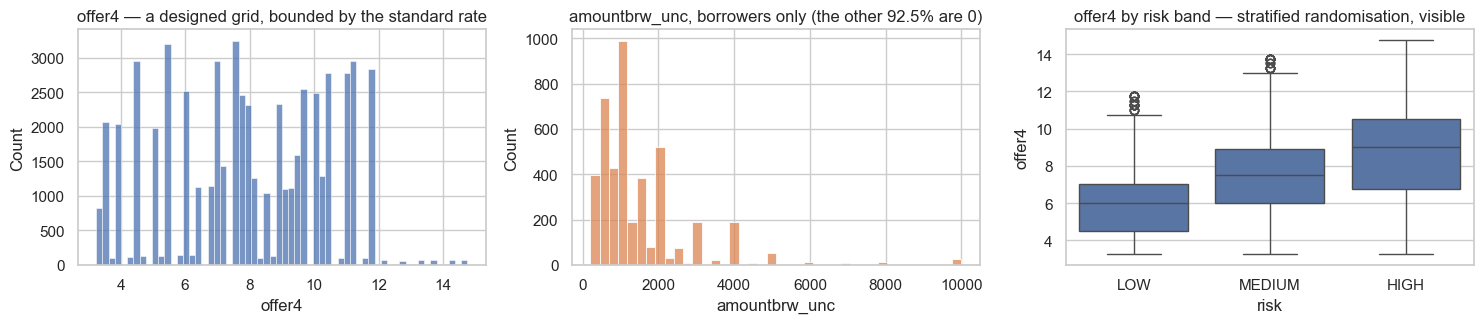

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
sns.histplot(df["offer4"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("offer4 — a designed grid, bounded by the standard rate")
sns.histplot(df.loc[df.tookup == 1, "amountbrw_unc"], bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("amountbrw_unc, borrowers only (the other 92.5% are 0)")
sns.boxplot(data=df, x="risk", y="offer4", order=["LOW", "MEDIUM", "HIGH"], ax=axes[2])
axes[2].set_title("offer4 by risk band — stratified randomisation, visible")
plt.tight_layout(); plt.show()

## 7. Row Granularity — and the fork

The deposit is one wide table at one grain. It holds two, and separating them is what gives the
pipeline the lesson it is built around: a table that **can** be loaded incrementally and a table
that structurally **cannot**.

* `mail_offers` — one row per mailer. It has an ordering column, `wave`, so it loads incrementally.
* `client_attributes` — a CRM snapshot, 1:1 with the spine, with **no event column at all**. Its
  `load_column` is `None` and it is reloaded in full on every run.

This is also where the geometry of `y` gets read and the path is chosen.

In [23]:
EVENT_COLS = ["wave", "offer4", "prize", "intshown", "dphoto_female", "dphoto_none",
              "dphoto_black", "gender_match", "race_match", "nspeakeligible", "speak_trt",
              "oneln_trt", "comploss_n", "use_any", "stripany", "comp_n", "deadlinemed",
              "deadlinelong", "deadlong_elig", "deadshort_elig", "deadlineshortext", "waved3",
              "applied", "tookup", "amountbrw_unc", "badacct_last", "applied_2weeks",
              "tookup_after_short", "tookup_after_med", "tookup_after_long",
              "tookup_outside_only"]
CLIENT_COLS = ["race", "risk", "female", "edhi", "dormancy", "trcount"]

assert set(EVENT_COLS) | set(CLIENT_COLS) == set(df.columns), "the split must be lossless"
assert not (set(EVENT_COLS) & set(CLIENT_COLS)), "no column may live in both"
print(f"{len(EVENT_COLS)} event columns + {len(CLIENT_COLS)} client columns = "
      f"{len(EVENT_COLS) + len(CLIENT_COLS)}, and the source has {df.shape[1]}. Nothing dropped, "
      f"nothing duplicated.")

df = df.reset_index(drop=True)
df.insert(0, "client_id", np.arange(1, len(df) + 1))     # 1-based row number, minted
mail_offers = df[["client_id"] + EVENT_COLS].copy()
client_attributes = df[["client_id"] + CLIENT_COLS].copy()

print(f"\n   mail_offers        {mail_offers.shape[0]:>6,} x {mail_offers.shape[1]:>2}   "
      f"grain: one row per mailer      load_column = 'wave'")
print(f"   client_attributes  {client_attributes.shape[0]:>6,} x {client_attributes.shape[1]:>2}"
      f"   grain: one row per client      load_column = None")

31 event columns + 6 client columns = 37, and the source has 37. Nothing dropped, nothing duplicated.

   mail_offers        58,168 x 32   grain: one row per mailer      load_column = 'wave'
   client_attributes  58,168 x  7   grain: one row per client      load_column = None


In [24]:
# Prove the second table really has nowhere to put a watermark, rather than asserting it.
candidates = [c for c in client_attributes.columns
              if pd.api.types.is_datetime64_any_dtype(client_attributes[c])
              or "date" in c.lower() or "time" in c.lower() or "wave" in c.lower()]
print(f"columns in client_attributes that could order a load: {candidates}")

verdict(True, "client_attributes has no event column of any kind, so load_column is None and "
              "every run ships all 58,168 rows. This is the table that makes the watermark "
              "worth externalising: if both tables were incremental, a hard-coded predicate "
              "would have worked and there would be nothing to configure")

print("\nRejected: minting a `created_at` so the table 'has to' be full_load. That would be a")
print("fabricated timestamp on a snapshot that genuinely has no event time — the wrong kind of")
print("invention, and different in kind from client_id, which is a row number over a fixed")
print("published file and claims nothing about when anything happened.")

columns in client_attributes that could order a load: []
APPLIES  — client_attributes has no event column of any kind, so load_column is None and every run ships all 58,168 rows. This is the table that makes the watermark worth externalising: if both tables were incremental, a hard-coded predicate would have worked and there would be nothing to configure

Rejected: minting a `created_at` so the table 'has to' be full_load. That would be a
fabricated timestamp on a snapshot that genuinely has no event time — the wrong kind of
invention, and different in kind from client_id, which is a row number over a fixed
published file and claims nothing about when anything happened.


### b. Read the geometry of `y` — the fork

In [25]:
# Three candidate targets, one per path. Measuring them is what picks the path.
print("Path 1 — continuous. Candidate: amountbrw_unc")
z = (df.amountbrw_unc == 0).mean()
print(f"   {z:.2%} of rows are exactly 0. A conditional mean is a mixture of 'did they borrow'")
print(f"   and 'how much', and the first term dominates. Not a continuous target.\n")

print("Path 2 — categorical. Candidate: badacct_last")
sub = df.badacct_last.notna().sum(); pos = int(df.badacct_last.sum())
print(f"   defined on {sub:,} rows of {len(df):,} ({sub/len(df):.2%}), {pos} positives "
      f"({pos/sub:.2%}).")
print(f"   The {sub:,} are self-selected on a randomised price AND passed a loan-officer screen,")
print(f"   with no unselected comparison group in the file. The randomisation — the only reason")
print(f"   this deposit is special — contributes nothing to a default model.\n")

print("Path 3 — bandit. Candidate: tookup, against a randomised action")
print(f"   reward {df.tookup.mean():.5f} over {len(df):,} rows, and the action (`offer4`) was")
print(f"   RANDOMLY ASSIGNED, stratified by risk band. Propensities are therefore recoverable")
print(f"   and off-policy evaluation is meaningful rather than decorative.")

verdict(True, "the fork fires on Path 3. Steps 8, 9 and 10 are now BANNED, and Step 4 has "
              "already been overridden above", override=True)

Path 1 — continuous. Candidate: amountbrw_unc
   92.47% of rows are exactly 0. A conditional mean is a mixture of 'did they borrow'
   and 'how much', and the first term dominates. Not a continuous target.

Path 2 — categorical. Candidate: badacct_last
   defined on 4,381 rows of 58,168 (7.53%), 517 positives (11.80%).
   The 4,381 are self-selected on a randomised price AND passed a loan-officer screen,
   with no unselected comparison group in the file. The randomisation — the only reason
   this deposit is special — contributes nothing to a default model.

Path 3 — bandit. Candidate: tookup, against a randomised action
   reward 0.07532 over 58,168 rows, and the action (`offer4`) was
   RANDOMLY ASSIGNED, stratified by risk band. Propensities are therefore recoverable
   and off-policy evaluation is meaningful rather than decorative.
OVERRIDE — the fork fires on Path 3. Steps 8, 9 and 10 are now BANNED, and Step 4 has already been overridden above


True

## 8. Conditional Logic and Dummy Variables

The action space. Six price arms inside each of the three risk bands, and the cut points are
**declared constants, not quantiles of the arriving data**.

That choice is the same one the sibling crypto-ticks project makes about its bar calendar, and
for the same reason: a grid recomputed per run makes round 1's "arm 3" a different price band
from round 3's, so the posterior would be accumulating counts across arms that are not the same
arm. A declared grid is comparable across runs. A derived one is not.

In [26]:
# Declared once, seeded into processed_zone.dim_offer_arm by the DDL, and duplicated here only
# so the notebook stands alone. An arm is  rate_floor <= offer_rate < rate_ceil,  top arm open.
DECLARED_CUTS = {
    "HIGH":   (5.50, 7.50, 9.00, 10.00, 11.00),
    "MEDIUM": (5.00, 6.75, 7.50,  8.25,  9.25),
    "LOW":    (4.50, 5.50, 6.00,  6.75,  7.50),
}
ARMS_PER_BAND = 6

def assign_arm(risk, rate):
    return int(np.searchsorted(DECLARED_CUTS[risk], rate, side="right"))

# np.select would need 18 conditions; searchsorted is the same decision expressed once. The
# `side="right"` is the whole contract: a rate exactly ON a cut belongs to the arm ABOVE it.
frame = mail_offers.merge(client_attributes[["client_id", "risk"]], on="client_id")
frame["arm"] = [assign_arm(r, o) for r, o in zip(frame.risk, frame.offer4)]

print("boundary behaviour, checked rather than assumed:")
for band, cuts in DECLARED_CUTS.items():
    for cut in cuts[:2]:
        below, at = assign_arm(band, cut - 0.01), assign_arm(band, cut)
        print(f"   {band:<7} rate {cut - 0.01:>5.2f} -> arm {below}   "
              f"rate {cut:>5.2f} -> arm {at}   (a rate on the cut goes up)")
        break

boundary behaviour, checked rather than assumed:
   HIGH    rate  5.49 -> arm 0   rate  5.50 -> arm 1   (a rate on the cut goes up)
   MEDIUM  rate  4.99 -> arm 0   rate  5.00 -> arm 1   (a rate on the cut goes up)
   LOW     rate  4.49 -> arm 0   rate  4.50 -> arm 1   (a rate on the cut goes up)


In [27]:
# Dummy variables. On Path 2 the framework ENFORCES one-hot before variance pruning. Here the
# one-hot is built to make the point that follows in section 11 -- it is never consumed.
arm_dummies = pd.get_dummies(frame["risk"] + "_arm" + frame["arm"].astype(str), prefix="")
print(f"one-hot over (band, arm): {arm_dummies.shape[1]} columns for "
      f"{len(DECLARED_CUTS) * ARMS_PER_BAND} declared arms")
print("\nexposure share within each band:")
shares = {}
for band in ["HIGH", "MEDIUM", "LOW"]:
    sub = frame[frame.risk == band]
    s = sub.groupby("arm").size() / len(sub)
    shares[band] = s
    print(f"   {band:<7} " + "  ".join(f"{v:.4f}" for v in s))
all_shares = pd.concat(shares.values())
print(f"\n   shares run {all_shares.min():.4f} .. {all_shares.max():.4f} — the logging policy is")
print(f"   NOT uniform, which is the only reason an importance weight below is ever != 1.")

one-hot over (band, arm): 18 columns for 18 declared arms

exposure share within each band:
   HIGH    0.1657  0.1654  0.1915  0.1454  0.1555  0.1764
   MEDIUM  0.1625  0.1539  0.1659  0.1919  0.1552  0.1707
   LOW     0.2351  0.1322  0.1523  0.1018  0.2786  0.0999

   shares run 0.0999 .. 0.2786 — the logging policy is
   NOT uniform, which is the only reason an importance weight below is ever != 1.


## 9. Feature Engineering

On this path there is no feature matrix. The bandit's context is the risk band, its action is the
arm, and the object it maintains is one posterior per `(context, action)` pair. That pairing **is**
the interaction term, and it is the only engineered feature the engine consumes.

In [28]:
# The interaction frame: 3 bands x 6 arms = 18 cells, and one set of counts per wave.
cells = (frame.groupby(["wave", "risk", "arm"])
              .agg(pulls=("tookup", "size"), rewards=("tookup", "sum"),
                   rate_lo=("offer4", "min"), rate_hi=("offer4", "max"))
              .reset_index())
print(f"{cells[['risk', 'arm']].drop_duplicates().shape[0]} (band, arm) cells "
      f"x {cells.wave.nunique()} waves = {len(cells)} (band, wave, arm) posteriors\n")
print(f"smallest cell: {cells.pulls.min()} rows "
      f"({cells.loc[cells.pulls.idxmin(), 'risk']} wave "
      f"{cells.loc[cells.pulls.idxmin(), 'wave']} arm {cells.loc[cells.pulls.idxmin(), 'arm']})")

verdict(True, f"Step 7 interaction frame built. Positivity holds: every one of the {len(cells)} "
              f"cells has at least {cells.pulls.min()} observations, so no propensity "
              f"denominator is zero and the importance weights below are all finite")

18 (band, arm) cells x 3 waves = 54 (band, wave, arm) posteriors

smallest cell: 79 rows (MEDIUM wave 1 arm 3)
APPLIES  — Step 7 interaction frame built. Positivity holds: every one of the 54 cells has at least 79 observations, so no propensity denominator is zero and the importance weights below are all finite


True

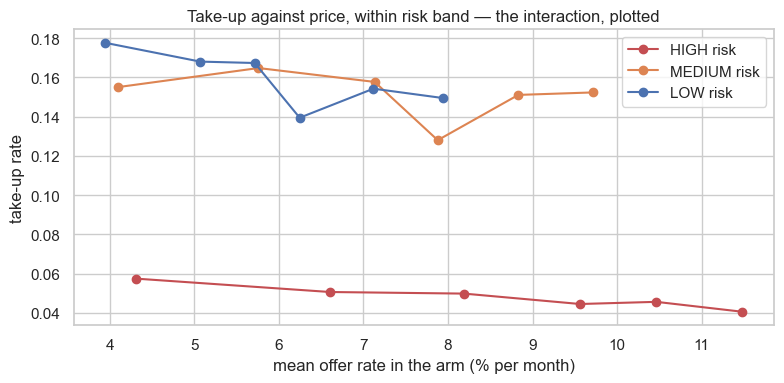

In [29]:
# A main-effects alternative would assert the price response has the same shape in every band.
# It does not, and this is the plot that says so.
pooled = (frame.groupby(["risk", "arm"])
               .agg(n=("tookup", "size"), rate=("tookup", "mean"),
                    mid=("offer4", "mean")).reset_index())
fig, ax = plt.subplots(figsize=(8, 4))
for band, colour in zip(["HIGH", "MEDIUM", "LOW"], ["#C44E52", "#DD8452", "#4C72B0"]):
    s = pooled[pooled.risk == band]
    ax.plot(s["mid"], s["rate"], "o-", color=colour, label=f"{band} risk")
ax.set_xlabel("mean offer rate in the arm (% per month)")
ax.set_ylabel("take-up rate")
ax.set_title("Take-up against price, within risk band — the interaction, plotted")
ax.legend(); plt.tight_layout(); plt.show()

## 10. Merging External Data

One external table, three numbers, read out of the paper: the lender's **standard** four-month
rate schedule. It is worth merging because it turns a bare rate into a discount, and because
reproducing the paper's own summary of it is the cheapest available check that this file is the
file the paper was written about.

In [30]:
# From the QJE paper: "The standard schedule for four-month loans was low-risk = 7.75% per
# month; medium-risk = 9.75%; high-risk = 11.75%."
standard_schedule = pd.DataFrame({
    "risk": ["LOW", "MEDIUM", "HIGH"],
    "standard_rate": [7.75, 9.75, 11.75],
})
frame = frame.merge(standard_schedule, on="risk", how="left")
frame["discount_vs_standard"] = frame["standard_rate"] - frame["offer4"]
assert frame["standard_rate"].notna().all(), "every row must find a band in the schedule"

paper_sample = frame[frame.wave.isin([2, 3])]
print("The paper's claims about its own sample, recomputed here:\n")
checks = [
    ("solicited clients",              f"{len(paper_sample):,}",                     "53,194"),
    ("mean rate (basis points)",       f"{paper_sample.offer4.mean() * 100:.0f}",    "793"),
    ("rate range",                     f"{paper_sample.offer4.min():.2f}-{paper_sample.offer4.max():.2f}",
                                                                                     "3.25-11.75"),
    ("offers below standard",          f"{(paper_sample.discount_vs_standard > 0).mean():.1%}",  "97%"),
    ("mean discount (pp)",             f"{paper_sample.discount_vs_standard.mean():.2f}",        "3.1"),
    ("applications becoming loans",    f"{paper_sample.tookup.sum() / paper_sample.applied.sum():.1%}",
                                                                                     "87%"),
    ("clients who obtained a loan",    f"{int(paper_sample.tookup.sum()):,}",        "~4,000"),
]
print(f"   {'quantity':<30} {'this file':>14}   {'paper':>12}")
for label, mine, theirs in checks:
    print(f"   {label:<30} {mine:>14}   {theirs:>12}")

verdict(True, "the external merge reproduces every published figure. That is the provenance "
              "check: the file, the column meanings and the risk bands are the ones the paper "
              "describes")

The paper's claims about its own sample, recomputed here:



   quantity                            this file          paper
   solicited clients                      53,194         53,194
   mean rate (basis points)                  793            793
   rate range                         3.25-11.75     3.25-11.75
   offers below standard                   96.8%            97%
   mean discount (pp)                       3.07            3.1
   applications becoming loans             87.2%            87%
   clients who obtained a loan             3,944         ~4,000
APPLIES  — the external merge reproduces every published figure. That is the provenance check: the file, the column meanings and the risk bands are the ones the paper describes


True

## 11. Feature Selection

**BANNED on Path 3.** Not skipped, not "not needed" — forbidden, with a named engine that breaks.

In [31]:
# Show exactly what a variance threshold would take, so the ban is a measurement and not a rule.
p = all_shares.sort_values()
print("a one-hot dummy for an arm played a fraction p of the time has variance p(1-p),")
print("so VarianceThreshold removes arms in ascending order of exposure:\n")
for rank, share in enumerate(p.values[:4], start=1):
    print(f"   {rank}. share {share:.4f}  variance {share * (1 - share):.5f}   <- removed first")

verdict(False, f"Step 8 prune: the thinnest arm has share {p.min():.4f}, and it is the arm the "
               f"posterior is LEAST certain about — which is precisely the arm Thompson "
               f"sampling most needs to keep drawing. Pruning it is how a bandit stops exploring",
        banned=True)
verdict(False, "Step 8 structural: the arms are the action space, not features. Deleting one "
               "does not simplify a model, it deletes a price the lender is allowed to offer — "
               "and it would still appear in the logged data, so the evaluation would be "
               "estimating a policy that cannot be run", banned=True)

a one-hot dummy for an arm played a fraction p of the time has variance p(1-p),
so VarianceThreshold removes arms in ascending order of exposure:

   1. share 0.0999  variance 0.08992   <- removed first
   2. share 0.1018  variance 0.09147   <- removed first
   3. share 0.1322  variance 0.11472   <- removed first
   4. share 0.1454  variance 0.12429   <- removed first
BANNED   — Step 8 prune: the thinnest arm has share 0.0999, and it is the arm the posterior is LEAST certain about — which is precisely the arm Thompson sampling most needs to keep drawing. Pruning it is how a bandit stops exploring
BANNED   — Step 8 structural: the arms are the action space, not features. Deleting one does not simplify a model, it deletes a price the lender is allowed to offer — and it would still appear in the logged data, so the evaluation would be estimating a policy that cannot be run


False

## 12. Feature Scaling

**BANNED on Path 3**, and this is the one that is easiest to do by reflex and hardest to notice
afterwards, because a standardised posterior still produces numbers.

In [32]:
from sklearn.preprocessing import StandardScaler

# Build the real posterior counts, then try to scale them, and watch the Beta stop existing.
PRIOR_A = PRIOR_B = 1.0
totals = cells.groupby(["risk", "arm"])[["pulls", "rewards"]].sum().reset_index()
alpha = PRIOR_A + totals.rewards.values.astype(float)
beta = PRIOR_B + (totals.pulls.values - totals.rewards.values).astype(float)

scaled = StandardScaler().fit_transform(np.column_stack([alpha, beta]))
non_positive = int((scaled <= 0).sum())
print(f"alpha ranges {alpha.min():.0f}..{alpha.max():.0f}, beta {beta.min():.0f}..{beta.max():.0f}")
print(f"after StandardScaler, {non_positive} of {scaled.size} shape parameters are <= 0\n")

try:
    np.random.default_rng(0).beta(scaled[:, 0], scaled[:, 1])
except ValueError as exc:
    print(f"   numpy's Beta sampler on the scaled parameters: ValueError({exc})")

verdict(False, f"Step 10 domain: the Beta density exists only for alpha > 0 and beta > 0, and "
               f"mean-centring puts {non_positive} of {scaled.size} shape parameters at or "
               f"below zero. The engine's one primitive has nothing to draw from", banned=True)

n_eff = alpha + beta
scaled_eff = (n_eff - n_eff.mean()) / n_eff.std()
print()
verdict(False, f"Step 10 evidence: alpha + beta is the arm's effective sample size and the whole "
               f"source of the explore/exploit signal. Standardising takes it from "
               f"{n_eff.min():,.0f}..{n_eff.max():,.0f} observations to "
               f"{scaled_eff.min():.4f}..{scaled_eff.max():.4f} units of sigma — every arm ends "
               f"up equally certain and the reason to explore is gone", banned=True)
verdict(False, "Step 10 conjugacy: the update adds a count to a count. After scaling, the state "
               "is in units of sigma while the increment is still one mailer, and mu and sigma "
               "move with every wave — so each round would add an integer to a quantity "
               "measured against a different basis from the one before it", banned=True)

alpha ranges 118..418, beta 701..7946
after StandardScaler, 22 of 36 shape parameters are <= 0

   numpy's Beta sampler on the scaled parameters: ValueError(a <= 0)
BANNED   — Step 10 domain: the Beta density exists only for alpha > 0 and beta > 0, and mean-centring puts 22 of 36 shape parameters at or below zero. The engine's one primitive has nothing to draw from

BANNED   — Step 10 evidence: alpha + beta is the arm's effective sample size and the whole source of the explore/exploit signal. Standardising takes it from 825..8,364 observations to -0.8290..1.7659 units of sigma — every arm ends up equally certain and the reason to explore is gone
BANNED   — Step 10 conjugacy: the update adds a count to a count. After scaling, the state is in units of sigma while the increment is still one mailer, and mu and sigma move with every wave — so each round would add an integer to a quantity measured against a different basis from the one before it


False

### The two framework steps the thirteen sections do not have a home for

The cleaning sections and the refinery's ten steps are different lists, and two of the ten fall
between sections here. They are run rather than assumed, so that every badge in the closing table
has a number printed under it.

In [33]:
# Step 6 -- TOPOLOGY. The framework's Path 3 entry is cyclical time coordinates.
waves = sorted(int(w) for w in frame.wave.unique())
temporal = [c for c in frame.columns
            if pd.api.types.is_datetime64_any_dtype(frame[c]) or pd.api.types.is_timedelta64_dtype(frame[c])]
print(f"ordering columns available : wave, with {len(waves)} distinct values {waves}")
print(f"time-typed columns in the frame : {len(temporal)} {temporal}")
verdict(False, f"Step 6 topology: a cyclical encoding needs a coordinate with a period. `wave` "
               f"has {len(waves)} values and no period — the mailers ran once each, in order, and "
               f"wave {waves[-1]} is not adjacent to wave {waves[0]}. Encoding it cyclically would "
               f"place the last batch of the experiment next to the first. There are "
               f"{len(temporal)} time-typed columns to derive a period from instead")

ordering columns available : wave, with 3 distinct values [1, 2, 3]
time-typed columns in the frame : 0 []
N/A      — Step 6 topology: a cyclical encoding needs a coordinate with a period. `wave` has 3 values and no period — the mailers ran once each, in order, and wave 3 is not adjacent to wave 1. Encoding it cyclically would place the last batch of the experiment next to the first. There are 0 time-typed columns to derive a period from instead


False

In [34]:
# Step 9 -- REGULARISATION. Banned, and the measurement is what an L1 penalty would do to the
# thinnest arms: shrink them toward the prior in proportion to how little support they have.
support = totals.set_index(["risk", "arm"]).pulls
thinnest = support.nsmallest(3)
widest = support.nlargest(1)
print("arm support, thinnest three against the widest:")
for (band, arm), n in list(thinnest.items()) + list(widest.items()):
    a = PRIOR_A + int(totals[(totals.risk == band) & (totals.arm == arm)].rewards.iloc[0])
    b = PRIOR_B + int(n) - (a - PRIOR_A)
    print(f"   {band:<7} arm {arm}  pulls {int(n):>6,}  posterior mean {a / (a + b):.5f}")
print(f"\nratio of widest to thinnest support: {widest.iloc[0] / thinnest.iloc[0]:.1f}x")
verdict(False, f"Step 9 regularise: an L1 penalty shrinks a coefficient toward zero in inverse "
               f"proportion to its support, so on this grid it would pull the "
               f"{int(thinnest.iloc[0]):,}-pull arm back onto the prior while barely touching the "
               f"{int(widest.iloc[0]):,}-pull one. The distance between an arm's posterior and the "
               f"prior is exactly what Thompson sampling reads to decide whether to explore it",
        banned=True)
verdict(False, "Step 9 structural: shrinkage is a bias-variance trade for a POINT estimate. The "
               "engine does not consume a point estimate — it draws from a posterior, and a "
               "shrunk mean with an unshrunk variance is not the posterior of anything",
        banned=True)

arm support, thinnest three against the widest:
   LOW     arm 5  pulls    823  posterior mean 0.15030
   LOW     arm 3  pulls    839  posterior mean 0.14031
   MEDIUM  arm 1  pulls    965  posterior mean 0.16546
   HIGH    arm 2  pulls  8,362  posterior mean 0.04998

ratio of widest to thinnest support: 10.2x
BANNED   — Step 9 regularise: an L1 penalty shrinks a coefficient toward zero in inverse proportion to its support, so on this grid it would pull the 823-pull arm back onto the prior while barely touching the 8,362-pull one. The distance between an arm's posterior and the prior is exactly what Thompson sampling reads to decide whether to explore it
BANNED   — Step 9 structural: shrinkage is a bias-variance trade for a POINT estimate. The engine does not consume a point estimate — it draws from a posterior, and a shrunk mean with an unshrunk variance is not the posterior of anything


False

## 13. Final Review — the engine, and what it actually found

Batched contextual Beta–Bernoulli Thompson sampling. Three rounds, one per wave, because a round
is exactly what one incremental extract delivers.

**No γ discount.** The framework's Path 3 engine carries γ = 0.97 for a stream, where an arm
accumulates rewards over time and older evidence should decay. Here each client is solicited
exactly once and no arm ever receives a second reward from the same unit, so there is no
non-stationarity for a discount to track and applying one would only throw away wave 1.

**This is a replay, not a live bandit.** Every mailer was sent, and its outcome recorded, before
this notebook existed. No client was ever solicited at a rate this posterior chose.

In [35]:
SEED = 20031001
DRAWS = 200_000
REPLICATES = 2_000
BANDS = ["HIGH", "MEDIUM", "LOW"]

# Two generators, spawned from one seed and independent by construction. If they shared a
# stream, consuming bootstrap draws would shift every Thompson draw that followed, and the
# reported policy value would silently depend on how many bootstrap replicates were run.
thompson_seed, bootstrap_seed = np.random.SeedSequence(SEED).spawn(2)
rng_ts = np.random.default_rng(thompson_seed)
rng_bs = np.random.default_rng(bootstrap_seed)

def counts(wave, band):
    s = cells[(cells.wave == wave) & (cells.risk == band)].set_index("arm")
    rewards = s.rewards.reindex(range(ARMS_PER_BAND), fill_value=0).values.astype(float)
    pulls = s.pulls.reindex(range(ARMS_PER_BAND), fill_value=0).values.astype(float)
    return rewards, pulls

def ts_policy(a, b, rng, n=DRAWS):
    """pi(arm | context) = P(this arm wins a posterior draw). A stochastic policy, so SNIPS
    is a weighted average over every row rather than a mean over the rows that agree."""
    draws = rng.beta(a[None, :], b[None, :], size=(n, len(a)))
    return np.bincount(draws.argmax(axis=1), minlength=len(a)) / n

def snips(pi, rewards, pulls):
    e = pulls / pulls.sum()                 # estimated logging propensity, per context
    w = np.where(pulls > 0, pi / np.where(e > 0, e, 1.0), 0.0)
    return float((w * rewards).sum() / (w * pulls).sum())

print(f"seed {SEED} | {DRAWS:,} Thompson draws | {REPLICATES:,} bootstrap replicates")

seed 20031001 | 200,000 Thompson draws | 2,000 bootstrap replicates


In [36]:
posterior = {b: (np.full(ARMS_PER_BAND, PRIOR_A), np.full(ARMS_PER_BAND, PRIOR_B)) for b in BANDS}
evaluation = []

for wave in sorted(cells.wave.unique()):
    if wave > 1:                                  # evaluate BEFORE this wave updates anything
        for band in BANDS:
            a, b = posterior[band]
            pi = ts_policy(a, b, rng_ts)
            rewards, pulls = counts(wave, band)
            n = int(pulls.sum())
            value = snips(pi, rewards, pulls)
            logging_value = rewards.sum() / pulls.sum()

            diffs = np.empty(REPLICATES)
            arm_of_row = np.repeat(np.arange(ARMS_PER_BAND), pulls.astype(int))
            y_of_row = np.concatenate([np.r_[np.ones(int(r)), np.zeros(int(p - r))]
                                       for r, p in zip(rewards, pulls)])
            for i in range(REPLICATES):
                idx = rng_bs.integers(0, n, size=n)
                a_i, y_i = arm_of_row[idx], y_of_row[idx]
                p_i = np.bincount(a_i, minlength=ARMS_PER_BAND).astype(float)
                r_i = np.bincount(a_i, weights=y_i, minlength=ARMS_PER_BAND)
                diffs[i] = snips(pi, r_i, p_i) - y_i.mean()

            evaluation.append(dict(wave=wave, band=band, n=n, logging=logging_value,
                                   snips=value, lift=100 * (value / logging_value - 1),
                                   ci_low=np.percentile(diffs, 2.5),
                                   ci_high=np.percentile(diffs, 97.5),
                                   p_positive=float((diffs > 0).mean())))
    for band in BANDS:                            # then the round's counts land
        rewards, pulls = counts(wave, band)
        a, b = posterior[band]
        posterior[band] = (a + rewards, b + (pulls - rewards))

print("posterior after wave 3 (Beta(1,1) prior, no discount):\n")
for band in BANDS:
    a, b = posterior[band]
    mean = a / (a + b)
    sd = np.sqrt(a * b / ((a + b) ** 2 * (a + b + 1)))
    print(f"   {band:<7} mean " + " ".join(f"{m:.5f}" for m in mean) + f"  | argmax arm {mean.argmax()}")
    print(f"   {'':<7} sd   " + " ".join(f"{s:.5f}" for s in sd)
          + f"  | best-worst = {(mean.max() - mean.min()) / sd.mean():.1f} sd")

posterior after wave 3 (Beta(1,1) prior, no discount):

   HIGH    mean 0.05762 0.05080 0.04998 0.04471 0.04580 0.04075  | argmax arm 0
           sd   0.00274 0.00258 0.00238 0.00259 0.00254 0.00225  | best-worst = 6.7 sd
   MEDIUM  mean 0.15573 0.16546 0.15835 0.12863 0.15179 0.15299  | argmax arm 1
           sd   0.01134 0.01194 0.01130 0.00964 0.01149 0.01099  | best-worst = 3.3 sd
   LOW     mean 0.17793 0.16865 0.16786 0.14031 0.15455 0.15030  | argmax arm 0
           sd   0.00868 0.01133 0.01054 0.01197 0.00754 0.01243  | best-worst = 3.6 sd


In [37]:
ev = pd.DataFrame(evaluation)
ev["clears_zero"] = (ev.ci_low > 0) | (ev.ci_high < 0)
print("off-policy evaluation — train on the earlier waves, evaluate on this one:\n")
print(f"   {'wave':>4} {'band':<7} {'n':>7} {'logging':>9} {'SNIPS':>9} {'lift':>8} "
      f"{'CI95 on the difference':>26} {'P(>0)':>7}")
for r in ev.itertuples():
    flag = "  <-- clear of zero" if r.clears_zero else ""
    print(f"   {r.wave:>4} {r.band:<7} {r.n:>7,} {r.logging:>9.5f} {r.snips:>9.5f} "
          f"{r.lift:>7.2f}% {f'[{r.ci_low:+.5f}, {r.ci_high:+.5f}]':>26} {r.p_positive:>7.3f}"
          f"{flag}")

print(f"\n{int(ev.clears_zero.sum())} of {len(ev)} intervals clear zero.")

off-policy evaluation — train on the earlier waves, evaluate on this one:

   wave band          n   logging     SNIPS     lift     CI95 on the difference   P(>0)
      2 HIGH     15,662   0.04731   0.04944    4.50%       [-0.00160, +0.00626]   0.867
      2 MEDIUM    1,911   0.13658   0.14152    3.62%       [-0.01408, +0.02401]   0.690
      2 LOW       3,423   0.16973   0.17852    5.18%       [-0.00534, +0.02223]   0.906
      3 HIGH     24,845   0.04882   0.05457   11.78%       [+0.00239, +0.00923]   1.000  <-- clear of zero
      3 MEDIUM    3,590   0.15348   0.15727    2.47%       [-0.01095, +0.02007]   0.694
      3 LOW       3,763   0.15865   0.14340   -9.62%       [-0.03193, +0.00207]   0.044

1 of 6 intervals clear zero.


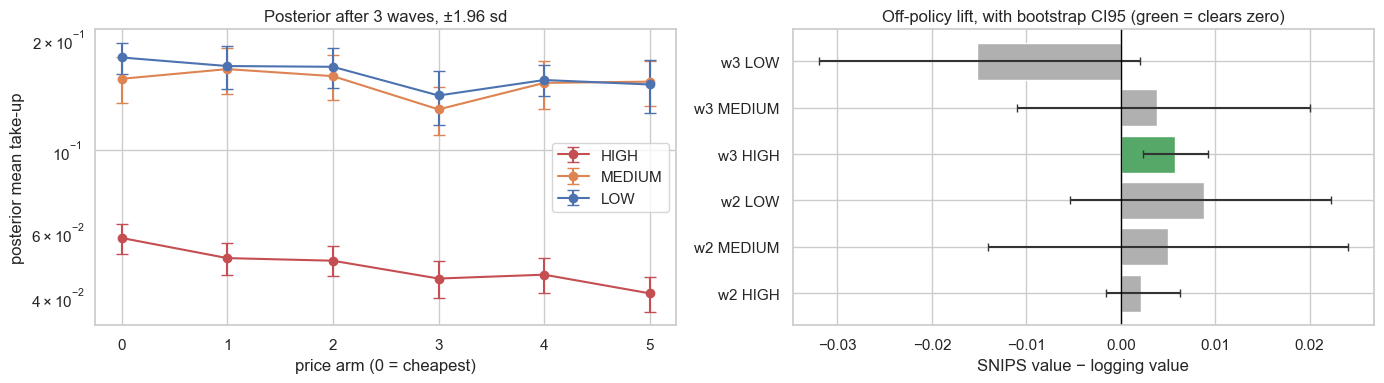

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for band, colour in zip(BANDS, ["#C44E52", "#DD8452", "#4C72B0"]):
    a, b = posterior[band]
    mean = a / (a + b)
    sd = np.sqrt(a * b / ((a + b) ** 2 * (a + b + 1)))
    axes[0].errorbar(range(ARMS_PER_BAND), mean, yerr=1.96 * sd, fmt="o-", capsize=4,
                     color=colour, label=band)
axes[0].set_xlabel("price arm (0 = cheapest)"); axes[0].set_ylabel("posterior mean take-up")
axes[0].set_title("Posterior after 3 waves, ±1.96 sd"); axes[0].legend(); axes[0].set_yscale("log")

y = np.arange(len(ev))
axes[1].barh(y, ev.snips - ev.logging, color=["#55A868" if c else "#B0B0B0"
                                              for c in ev.clears_zero])
axes[1].errorbar(ev.snips - ev.logging, y,
                 xerr=[ (ev.snips - ev.logging) - ev.ci_low, ev.ci_high - (ev.snips - ev.logging)],
                 fmt="none", ecolor="#333333", capsize=3)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_yticks(y); axes[1].set_yticklabels([f"w{r.wave} {r.band}" for r in ev.itertuples()])
axes[1].set_xlabel("SNIPS value − logging value")
axes[1].set_title("Off-policy lift, with bootstrap CI95 (green = clears zero)")
plt.tight_layout(); plt.show()

### What this found, stated plainly

**One of six evaluated cells has an interval clear of zero**, and it is the band where the arms
actually separate. HIGH risk on wave 3: the posterior means run 0.0576 down to 0.0408 against
standard deviations near 0.0025, so best and worst are more than six standard deviations apart,
and the learned policy beats the lender's own randomisation by a margin the bootstrap can see.

**One cell came out negative.** LOW risk on wave 3, −9.6%. The policy trained on waves 1–2 did
*worse* than randomising. The reason is visible in the posterior: LOW's top three arms sit at
0.1779, 0.1687 and 0.1679 against standard deviations near 0.010, which is under one standard
deviation apart. Its greedy arm moves 1 → 2 → 0 across the three rounds and never settles. A
confident policy over arms that do not separate is an overconfident policy, and this is what that
costs.

That is the result. Four of six cells cannot be distinguished from the logging policy at all, and
saying so is the point — a bandit run over a two-round history, on cells running from 1,911 rows
up to 24,845, was never going to produce six wins, and a write-up that reported only the HIGH
number would be describing a different experiment.

**What none of this establishes.** The propensities are *estimated* from the logged assignment
frequencies, because the randomisation design document is not published. The rate was genuinely
randomised, so the estimate is unbiased — but SNIPS with an estimated propensity is not the
guarantee that SNIPS with a known one would be. And no client was ever mailed at a price this
posterior chose.

### Sections that returned N/A or BANNED on this dataset

| Section | Verdict | Why |
| --- | --- | --- |
| 4. Inconsistent text | APPLIES, not repaired | `risk` and `race` disagree about case, but neither is a typo — the decision is *where* to normalise, and the answer is `processed_zone`, not the landing zone |
| 5. Duplicate rows | APPLIES, not dropped | 134 exact duplicate rows are kept: dropping them puts waves 2+3 at 53,175 against the paper's published 53,194 |
| 6. Outliers | N/A on all four columns | `offer4` is flagged by neither rule — it is a randomised treatment on a designed grid; `amountbrw_unc` is flagged on all 4,381 borrowers, which is the 1.5-IQR fence rediscovering a 92.47% spike at zero; `trcount`'s tail is real and kept; `dormancy` flags nothing |
| Step 6. Cyclical topology | N/A | `wave` is an ordinal batch index with three values and no period. Wave 3 is not adjacent to wave 1, and the star carries no time-typed column at all |
| Step 8. Feature selection | **BANNED** | variance pruning removes arms in ascending order of exposure — the thinnest arm is the one the posterior is least certain about, and the one Thompson sampling most needs to keep |
| Step 9. Regularisation | **BANNED** | L1 shrinks thin arms back onto the prior, and the distance between an arm's posterior and the prior *is* the explore signal |
| Step 10. Feature scaling | **BANNED** | mean-centring puts most Beta shape parameters at or below zero, where the density does not exist; and α+β is the effective sample size the explore/exploit trade is computed from |
| Step 4. Imputation | **OVERRIDE** | the framework's default fill is replaced by keeping native missingness as a latent state — wave 1's NULLs mean "this arm did not exist yet" |

Every one of those cells still runs its detection code, so re-pointing `RAW_PATH` at a different
extract will make them fire without any edit.